In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



In [3]:
spotify_df = pd.read_csv("../data/Cleaned_Spotify_2024_Global_Streaming_Data.csv")
spotify_df.head()

,Country,Artist,Album,Genre,Release Year,Monthly Listeners (Millions),Total Streams (Millions),Total Hours Streamed (Millions),Avg Stream Duration (Min),Platform Type,Streams Last 30 Days (Millions),Skip Rate (%)
0,Germany,Taylor Swift,1989 (Taylor's Version),K-pop,2020,23.10,3695.53,14240.35,4.28,Free,118.51,2.24
1,Brazil,The Weeknd,After Hours,R&B,2023,60.60,2828.16,11120.44,3.90,Premium,44.87,23.98
2,United States,Post Malone,Austin,Reggaeton,2019,42.84,1425.46,4177.49,4.03,Free,19.46,4.77
3,Italy,Ed Sheeran,Autumn Variations,K-pop,2019,73.24,2704.33,12024.08,3.26,Premium,166.05,25.12
4,Italy,Ed Sheeran,Autumn Variations,R&B,2019,7.89,3323.25,13446.32,4.47,Free,173.43,15.82


# Bar Charts 

In [6]:
# group by genre and calculate the average total streams 

avg_streams = spotify_df.groupby("Genre")["Total Streams (Millions)"].mean().sort_values(ascending=False)
avg_streams

Genre
R&B          2779.311707
K-pop        2760.691667
Classical    2739.955417
Pop          2686.797500
Indie        2661.669400
Rock         2558.947069
EDM          2466.699804
Jazz         2408.460000
Reggaeton    2404.313636
Hip Hop      2284.867551
Name: Total Streams (Millions), dtype: float64

<BarContainer object of 10 artists>

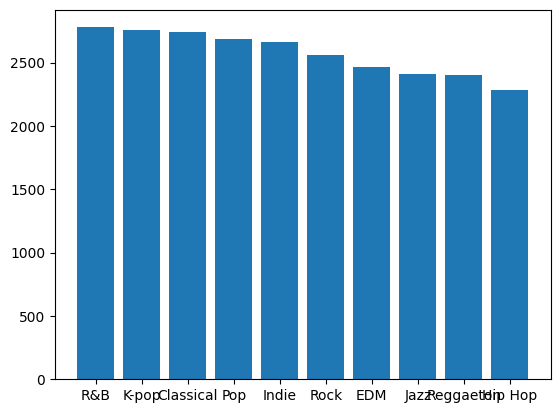

In [7]:
plt.bar(avg_streams.index, avg_streams.values)

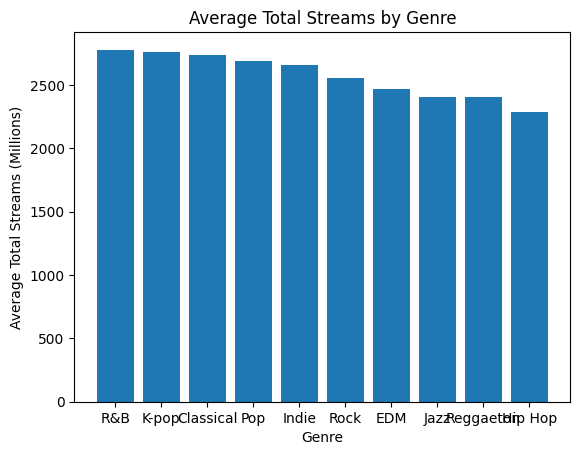

In [8]:
plt.bar(avg_streams.index, avg_streams.values)
plt.xlabel("Genre")
plt.ylabel("Average Total Streams (Millions)")
plt.title("Average Total Streams by Genre")
plt.show()

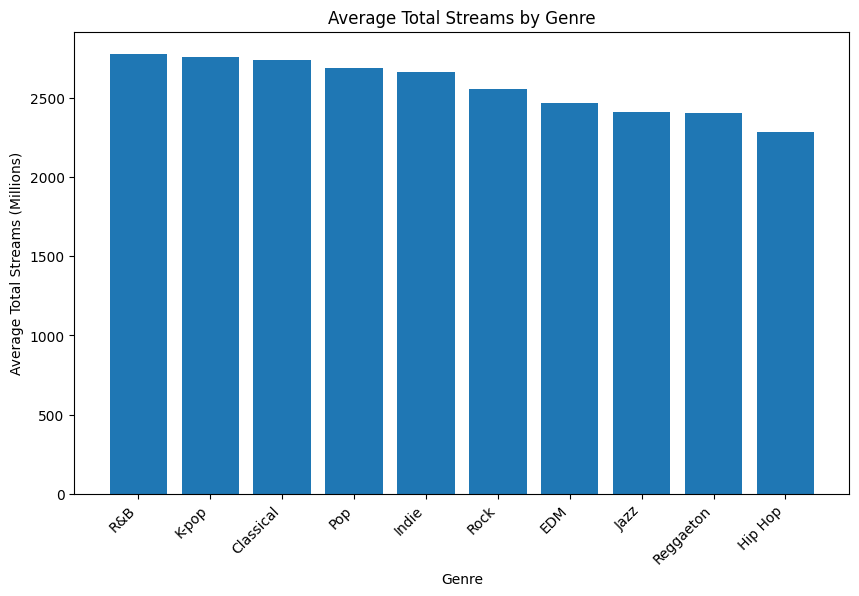

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(avg_streams.index, avg_streams.values)
plt.xlabel("Genre")
plt.ylabel("Average Total Streams (Millions)")
plt.title("Average Total Streams by Genre")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

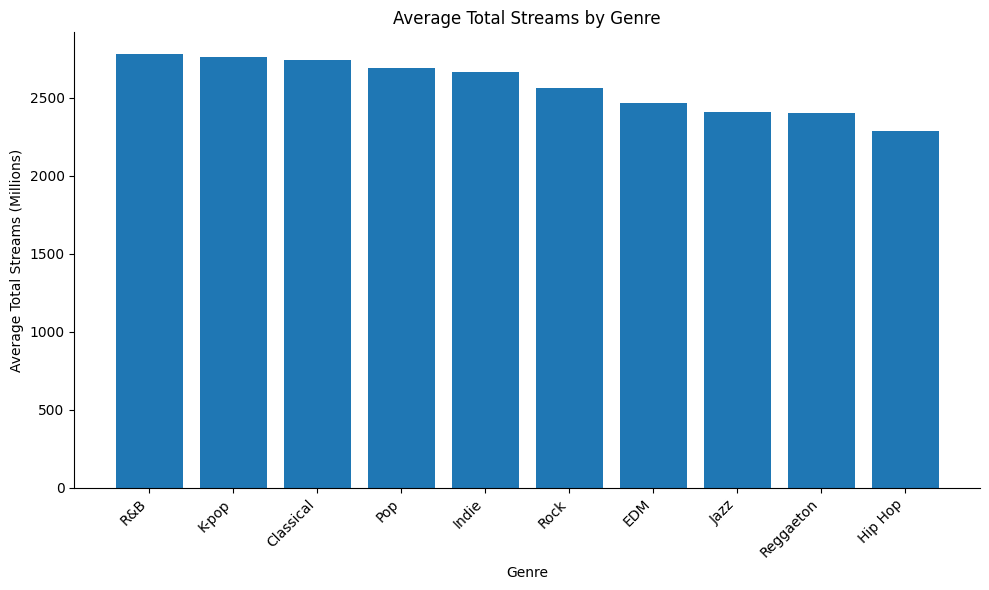

In [12]:
plt.figure(figsize=(10, 6))

plt.bar(avg_streams.index, avg_streams.values)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel("Genre")
plt.ylabel("Average Total Streams (Millions)")
plt.title("Average Total Streams by Genre")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

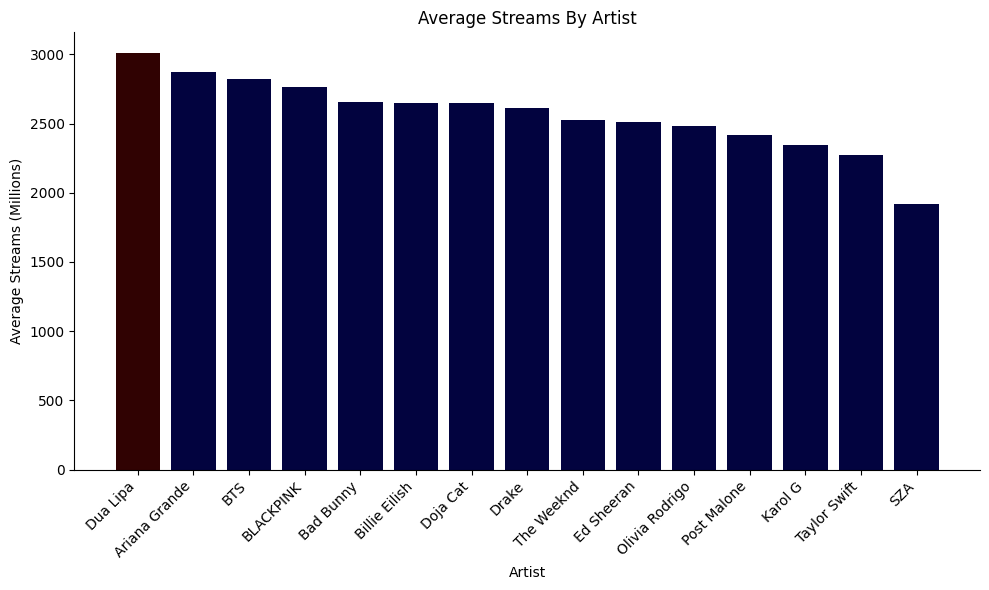

In [16]:
avg_artist_streams = spotify_df.groupby("Artist")["Total Streams (Millions)"].mean().sort_values(ascending=False)
avg_artist_streams

plt.figure(figsize=(10, 6))
colors = ["#02033F"]*len(avg_artist_streams)

max_index = avg_artist_streams.idxmax()
highlight_position = avg_artist_streams.index.get_loc(max_index)
colors[highlight_position] = "#300202"

plt.bar(avg_artist_streams.index, avg_artist_streams.values, color=colors, width=0.8)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel("Artist")
plt.ylabel("Average Streams (Millions)")
plt.title("Average Streams By Artist")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

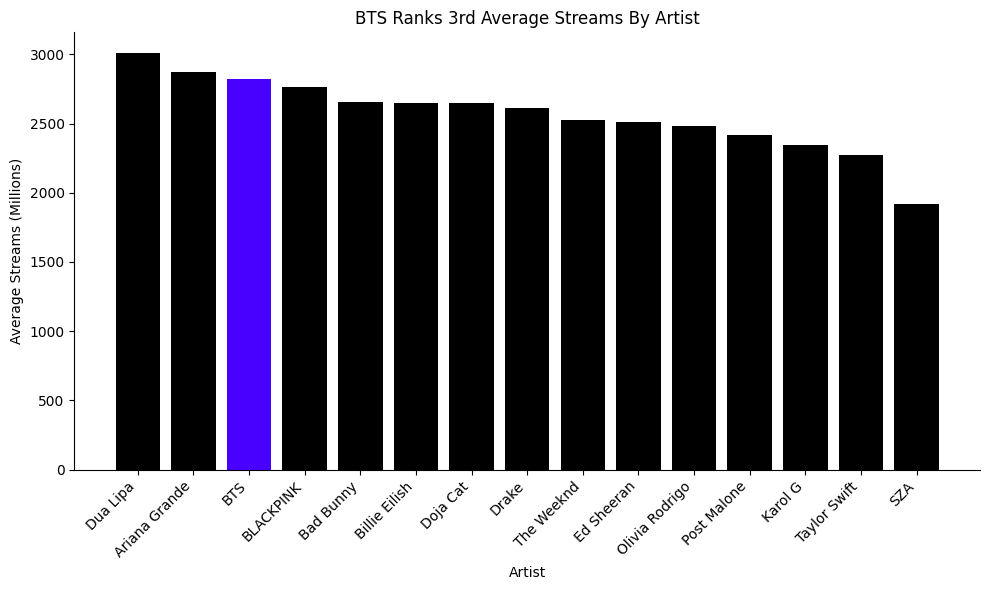

In [18]:
avg_artist_streams = spotify_df.groupby("Artist")["Total Streams (Millions)"].mean().sort_values(ascending=False)
avg_artist_streams

plt.figure(figsize=(10, 6))

special_artist = "BTS"
colors = ["#4800ff" if artist == special_artist else "black" for artist in avg_artist_streams.index]



plt.bar(avg_artist_streams.index, avg_artist_streams.values, color=colors, width=0.8)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel("Artist")
plt.ylabel("Average Streams (Millions)")
plt.title("BTS Ranks 3rd Average Streams By Artist")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Scatter Plots 

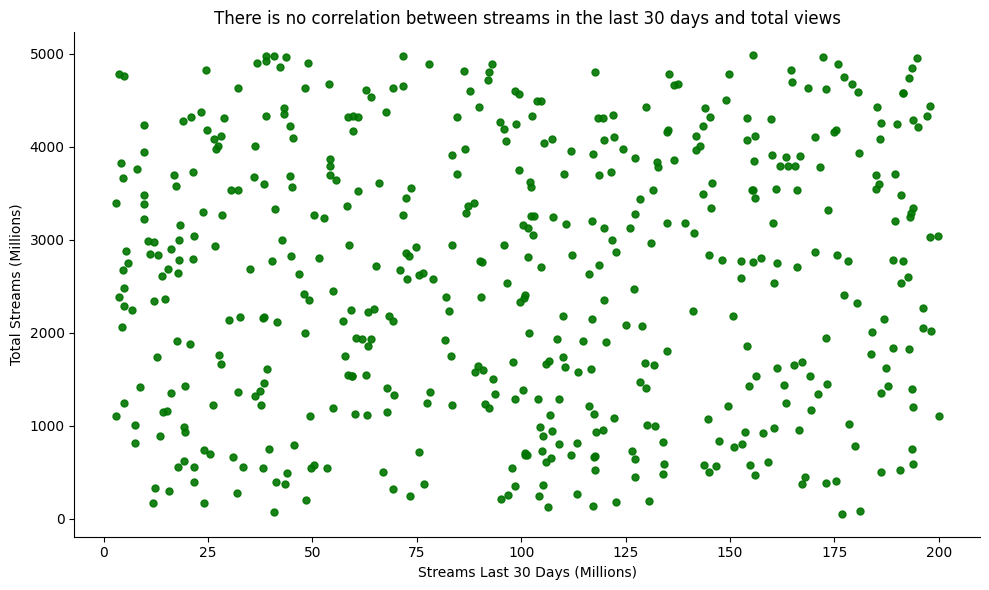

In [25]:
plt.figure(figsize=(10, 6))

plt.scatter(spotify_df["Streams Last 30 Days (Millions)"],
             spotify_df["Total Streams (Millions)"],
             color="#007400",
             alpha=0.9,
             s=25)
plt.xlabel("Streams Last 30 Days (Millions)")
plt.ylabel("Total Streams (Millions)")
plt.title("There is no correlation between streams in the last 30 days and total views")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

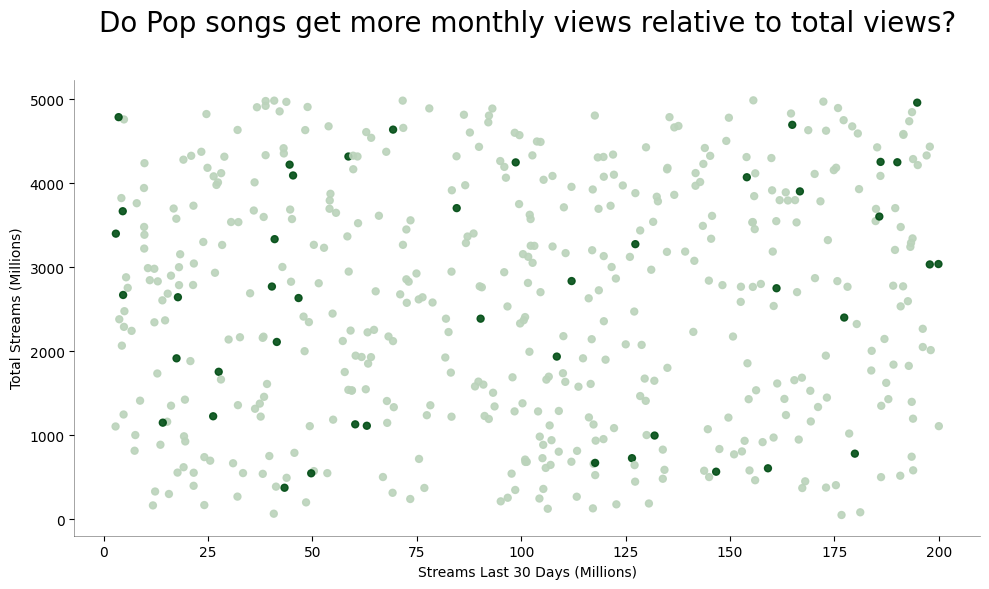

In [ ]:
plt.figure(figsize=(10, 6))

featured_genre = "Pop"

colors = ["#004D14" if genre == featured_genre else "#BBD3BB" for genre in spotify_df["Genre"]]

plt.scatter(spotify_df["Streams Last 30 Days (Millions)"],
             spotify_df["Total Streams (Millions)"],
             color= colors,
             alpha=0.9,
             s=25)
plt.xlabel("Streams Last 30 Days (Millions)")
plt.ylabel("Total Streams (Millions)")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Do Pop songs get more monthly views relative to total views?", fontsize=20, pad=35)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)


plt.tight_layout()

plt.show()

# Line Chart

In [33]:
yearly_avg = spotify_df.groupby("Release Year")["Total Streams (Millions)"].mean().round(2)
yearly_avg

Release Year
2018    2611.26
2019    2516.45
2020    2569.62
2021    2763.21
2022    2367.99
2023    2817.97
Name: Total Streams (Millions), dtype: float64

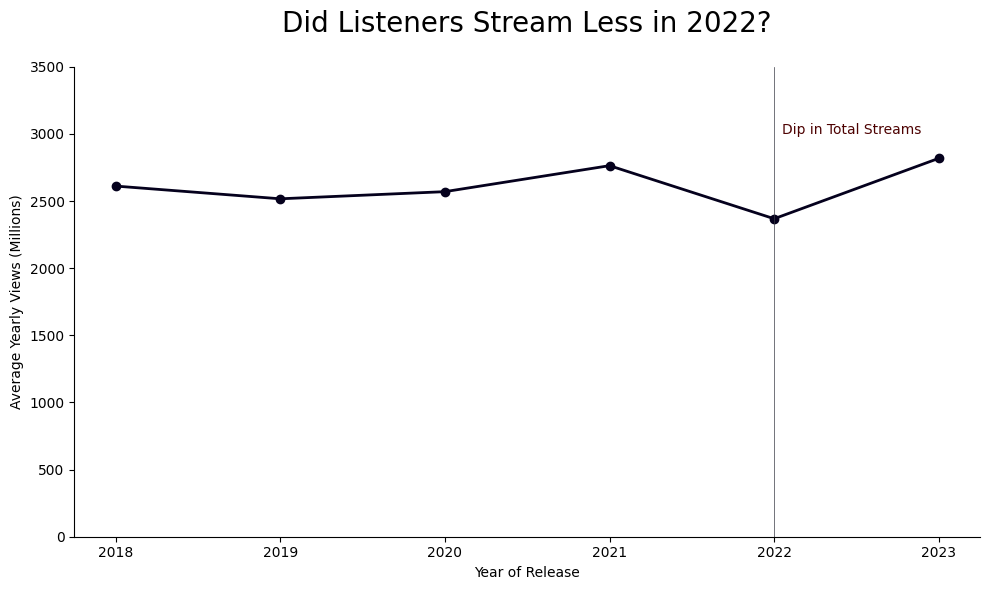

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(yearly_avg.index,
          yearly_avg.values,
          marker="o",
          linestyle="-",
          color="#05011D",
          linewidth=2)

plt.xlabel("Year of Release")
plt.ylabel("Average Yearly Views (Millions)")
plt.title("Did Listeners Stream Less in 2022?", fontsize=20, pad=25)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    2022+0.05, 
    3000,
    "Dip in Total Streams",
    color="#4d0202"
)

ax.axvline(
    2022,
    linewidth = 0.5, 
    color = "#3a3b45"
)

plt.ylim(0, 3500)

plt.tight_layout()
plt.show()

# Pie Chart

In [48]:
category = "Platform Type"
values = "Total Streams (Millions)"

platform_totals = spotify_df.groupby(category)[values].sum()
platform_totals

Platform Type
Free       638685.97
Premium    651891.07
Name: Total Streams (Millions), dtype: float64

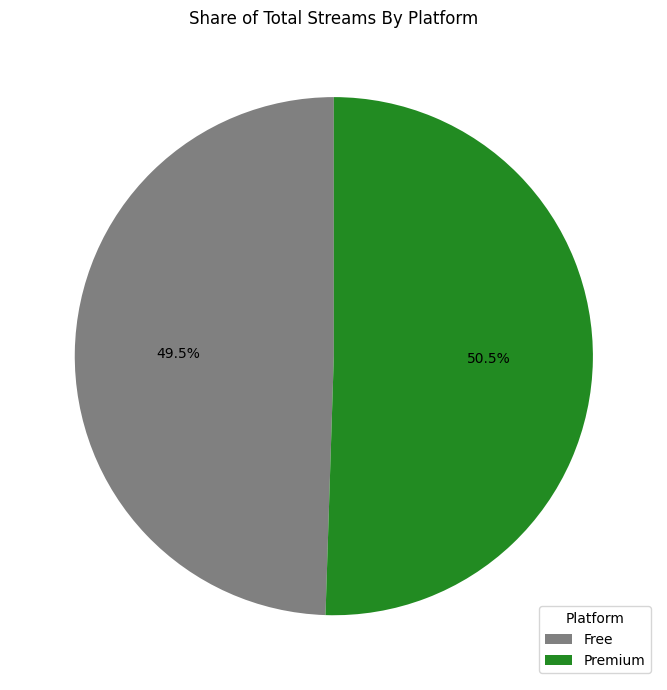

In [58]:
plt.figure(figsize=(7,7))
plt.pie(platform_totals, 
        labels=None,
        startangle=90,
        colors=['gray', 'forestgreen'],
        autopct="%1.1f%%"
        )
plt.title("Share of Total Streams By Platform")

plt.legend(
    labels=platform_totals.index,
    loc="lower right", 
    title="Platform"
)
plt.tight_layout()
plt.show()

# Histogram - great for showing distribution 

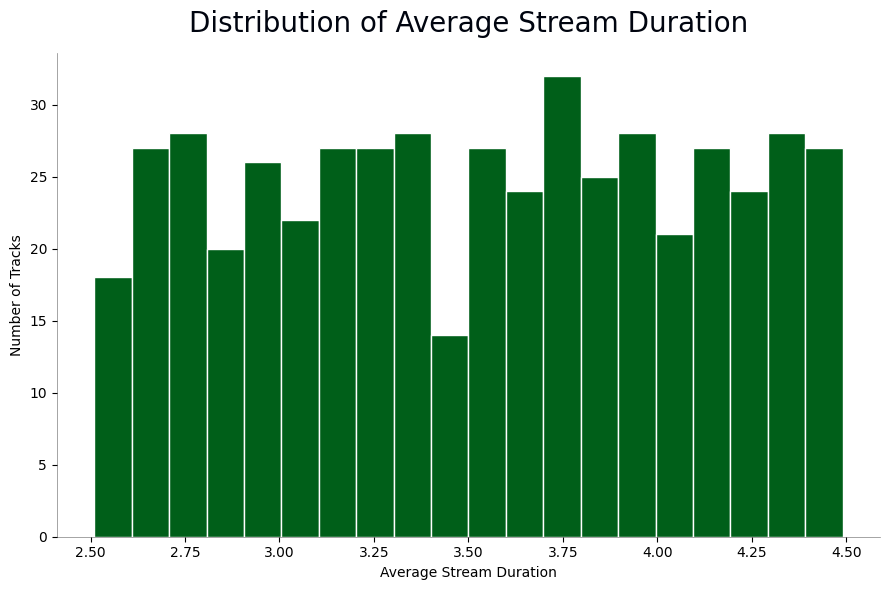

In [64]:
plt.figure(figsize=(9,6))

plt.hist(
    spotify_df["Avg Stream Duration (Min)"],
    bins=20,
    color="#005f19", 
    edgecolor= "white"
    )

plt.xlabel("Average Stream Duration")
plt.ylabel("Number of Tracks")
plt.title("Distribution of Average Stream Duration", fontsize=20, pad=15, color="#00040f")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)


plt.tight_layout()
plt.show()

# Boxplots 

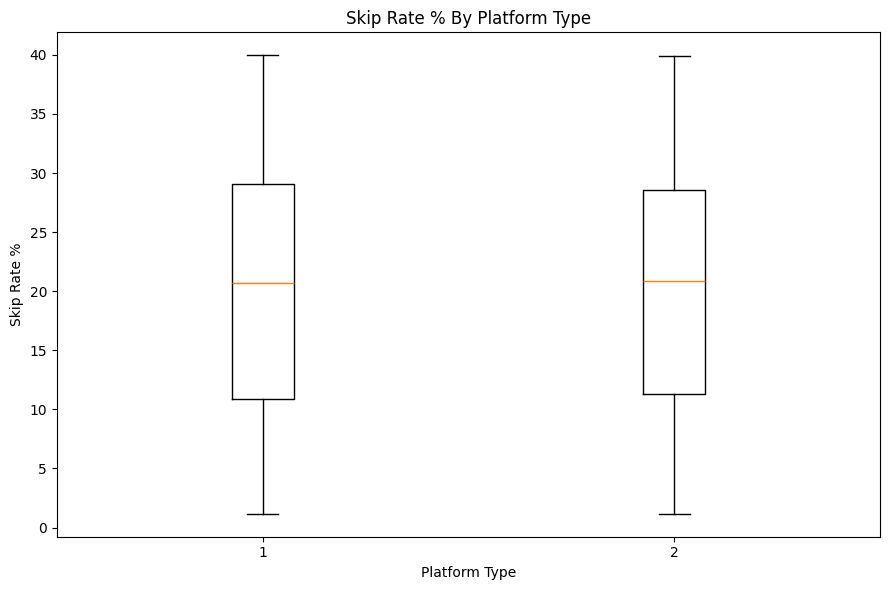

In [82]:
plt.figure(figsize=(9,6))
plt.boxplot(
    [spotify_df[spotify_df["Platform Type"] == "Free"]["Skip Rate (%)"],
     spotify_df[spotify_df["Platform Type"] == "Premium"]["Skip Rate (%)"]]
)

plt.xlabel("Platform Type")
plt.ylabel("Skip Rate %")
plt.title("Skip Rate % By Platform Type")

plt.tight_layout()
plt.show()

# Heat Map - for showing correllations between numberical data

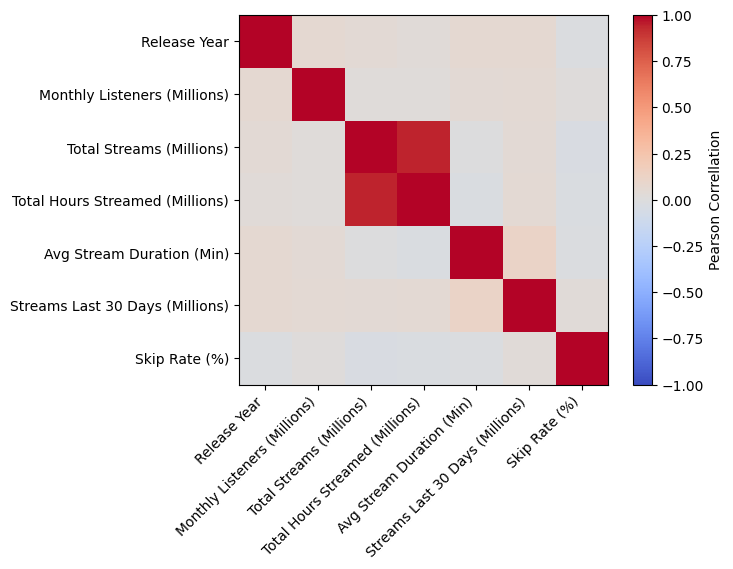

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

spotify_df = pd.read_csv("../data/Cleaned_Spotify_2024_Global_Streaming_Data.csv")
numeric_spotify_df = spotify_df.select_dtypes(include=[np.number])
corr = numeric_spotify_df.corr()

im = plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im, label="Pearson Correllation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

# Count Plot

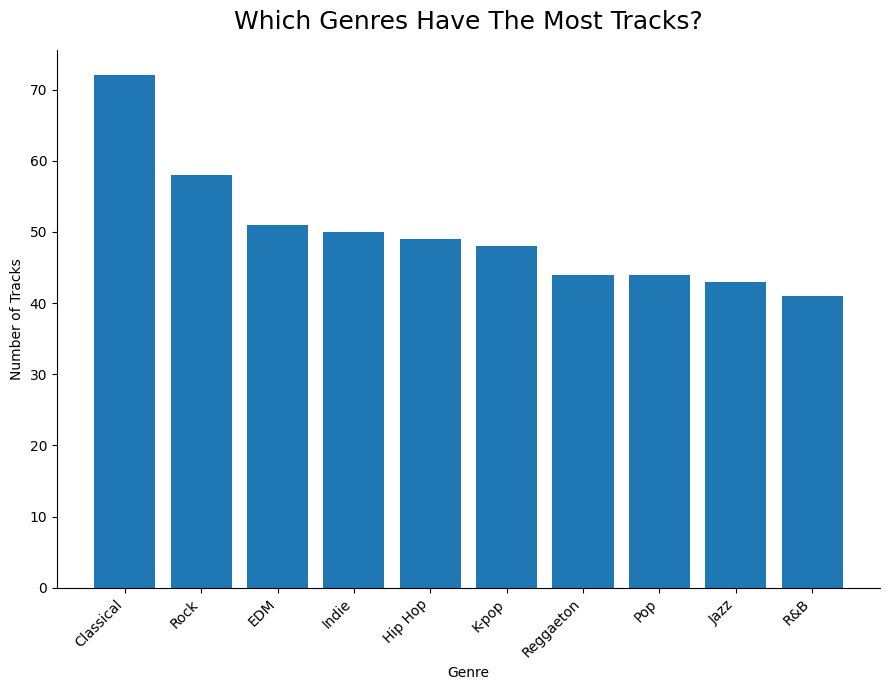

In [16]:
genre_counts = spotify_df["Genre"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(9,7))
plt.bar(genre_counts.index, genre_counts.values)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.title("Which Genres Have The Most Tracks?", fontsize=18, pad=15)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()